# Joys & sorrows of the astro-person: datasets & catalogues

You will eventually encounter in your research these guys.

Either containing stellar tracks, dark matter haloes, spectra, images..

Either being real or simulated

Both if you are a theoretician or an observational astronomer (or cosmologist), you will have to deal with datasets.
And in general these datasets are organised in catalogues (or similar).

Fear not! Python is a great language for the inspection and analysis of these entities!

* **ASCII**
     - **TXT**
     - **CSV**
* **BINARY**
     - **FITS**
     - **HDF5**
     - **Pickle**


To analyse the datasets:

In [3]:
#pip install numpy

In [4]:
import numpy

To move around the filesystem:

In [5]:
import os

Some coordinates:

In [6]:
basedir = '/home/carlabertacche/myproject/PracticalProgrammingToolkit/hands_on/H03/datasets'

## Load a dataset from ASCII

In [7]:
import os
print(os.getcwd())


/home/carlabertacche/myproject/PracticalProgrammingToolkit


In [8]:
os.listdir(basedir)

['TRECS_HI+Continuum_z0.01.fits',
 'SFR_density_function.npz',
 'haloes_64Mpc_512p_planck18_z3.txt',
 'Catalogue_FluxLim_z0.01.hdf5',
 'haloes_64Mpc_512p_planck18.txt']

In [9]:
os.path.join(basedir,'haloes_64Mpc_512p_planck18_z3.txt')

'/home/carlabertacche/myproject/PracticalProgrammingToolkit/hands_on/H03/datasets/haloes_64Mpc_512p_planck18_z3.txt'

In [10]:
Masses = numpy.genfromtxt(os.path.join(basedir,'haloes_64Mpc_512p_planck18_z3.txt'), 
                          usecols=(3,), unpack=True)
Lbox = 64 # Mpc/h
Volume = Lbox**3 # (Mpc/h)^3
Npart = 512**3

But first let's inspect what we have loaded, e.g.

* limits:

In [11]:
type(Masses), Masses.shape, Masses.size

(numpy.ndarray, (129914,), 129914)

In [12]:
Masses

array([2.0937e+13, 7.9169e+12, 1.0367e+13, ..., 4.8571e+09, 2.4286e+09,
       2.9490e+09], shape=(129914,))

In [13]:
Masses.argmin()

np.int64(8970)

In [14]:
(Masses.min(), Masses.max())

(np.float64(0.0), np.float64(20937000000000.0))

We do not like those zeros, so we are going to mask them!

In [15]:
wMn0 = Masses > 0.0

In [16]:
wMn0.size

129914

In [17]:
Masses[wMn0].size

126539

In [18]:
Masses = Masses[Masses > 0.0]

In [19]:
numpy.log10((Masses.min(), Masses.max()))

array([ 8.93818938, 13.32091445])

Great, how many values do we have?

In [20]:
Masses.size

126539

## Let's do some visual inspection with ``matplotlib``

Where to start: [the examples page](https://matplotlib.org/stable/gallery/index.html) 

In [21]:
#pip install matplotlib

In [22]:
import matplotlib.pyplot as plt

We want to compute the halo mass function

$$n(M_\text{halo}) = \dfrac{d n(M_\text{halo} \in [M,M+dM))}{d\ln M_\text{halo}}$$

is given by the **numerical density of haloes per logarithmic mass bin**.

In [23]:
NMDM, MDM_bins = numpy.histogram(Masses, bins=numpy.logspace(8.5, 14, 21))

In [24]:
MDM = 0.5 * (MDM_bins[1:]+MDM_bins[:-1])

In [25]:
dlnMDM = numpy.diff(numpy.log(MDM_bins))

In [26]:
nMDM = NMDM / dlnMDM / Volume

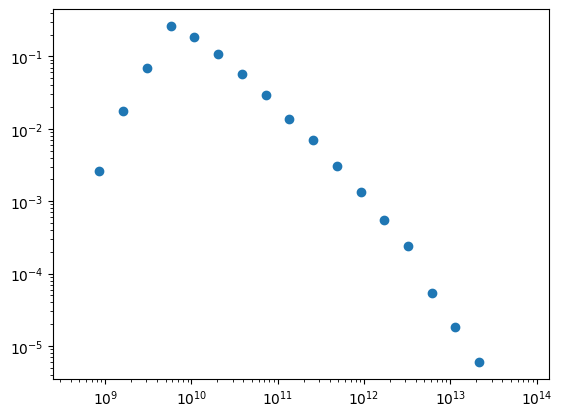

In [27]:
plt.loglog(MDM, nMDM, marker='o', linestyle='none')

Remember that we are scientists, what do we miss here? **THE ERROR!!!!**

In [28]:
nMDM_err = numpy.sqrt(NMDM) / dlnMDM / Volume

And maybe some physical limit to assess the validity of the data-set

In [29]:
#!pip install astropy

In [30]:
from astropy.cosmology import Planck18
import astropy.units as u

In [31]:
Mpart = (Planck18.critical_density0*Planck18.Odm0).to(u.Msun/(u.Mpc)**3)*Volume/Npart

In [32]:
Mpart*100

<Quantity 6.46902313e+09 solMass / Mpc3>

So a better way of plotting this bad guy is as follows

In [33]:
Mpart.value

np.float64(64690231.339792654)

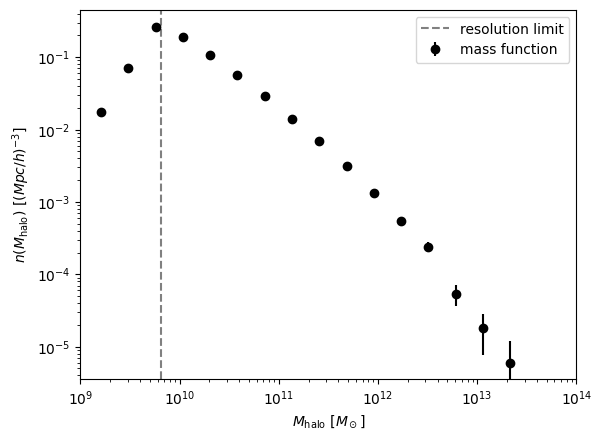

In [34]:
fig, ax = plt.subplots(1,1)

ax.set(
    xscale='log', yscale='log', 
    xlim=(1.e+9, 1.e+14),
    xlabel='$M_\\mathrm{halo}\\ [M_\\odot]$',
    ylabel='$n(M_\\mathrm{halo})\\ [(Mpc/h)^{-3}]$'
)
ax.errorbar(MDM, nMDM, yerr=nMDM_err, ls='none', marker = 'o', color='k', label='mass function')
ax.axvline(Mpart.value*100, color='gray', ls='--', label='resolution limit')
ax.legend()

and you could store it, also in a second moment:

In [35]:
#fig.savefig('mass_function.png', bbox_inches='tight')

## FITS files 

Stands for **Flexible Image Transport System** and by the name you can infer why it is so used in astronomy.
We will not work with images today, but consider that an image, most of the times, is just a 2D (one single channel) or a 3D (multiple channels) **MATRIX**.

Therefore fits is a file format that is optimised to work with multi-dimensional arrays.

It stores **data AND metadata** in binary format.

Generates Header-Data Units (HDUs), which both contain the dataset and descriptive meta-data.

> **metadata** are all of the informations on the dataset at hand that are useful to understand the actual dataset

**Last but not least** since the nature of the metadata associated with a dataset encompasses also
- the shape of a dataset
- the data-type
- where in the file the target dataset is stored
FITS allows to not directly load in memory the dataset but only a **MEMORY MAP** of the dataset.
This means it is possible to work with files larger than the available volatile memory of your system (at the cost of performances).

The file we will use as example:

In [36]:
filename = 'TRECS_HI+Continuum_z0.01.fits'

[AstroPy](https://www.astropy.org/) is a useful library that contains a lot of stuff useful to the astronomer.

**BUT REMEMBER THAT IT ALSO MISSES A LOT OF STUFF: DON'T RELY ON IT TOO MUCH**

In [37]:
from astropy.io import fits

By opening a ``fits`` file you are given a **LIST OF HDUs**

In [38]:
hdul = fits.open(os.path.join(basedir, filename.format(0.01)))

You can get some metadata on this:

In [39]:
hdul.info()

Filename: /home/carlabertacche/myproject/PracticalProgrammingToolkit/hands_on/H03/datasets/TRECS_HI+Continuum_z0.01.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  Catalogue     1 BinTableHDU    174   10123R x 73C   [D, D, D, E, D, E, E, D, D, E, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D]   


Each HDU comes with an header

In [40]:
#hdul[0].header

In [41]:
#hdul[1].header

Since it is conceptually a table, you can access the different columns by calling the sub-object ``columns``

In [42]:
#hdul[1].columns.names

We can assign it to a variable for convenience:

In [43]:
columns = hdul[1].columns.names

## Once again on visual inspection with ``matplotlib``

### Redshift distribution

In [44]:
zz = hdul[1].data['redshift']

In [45]:
# zz = numpy.array(hdul[1].data['redshift'])

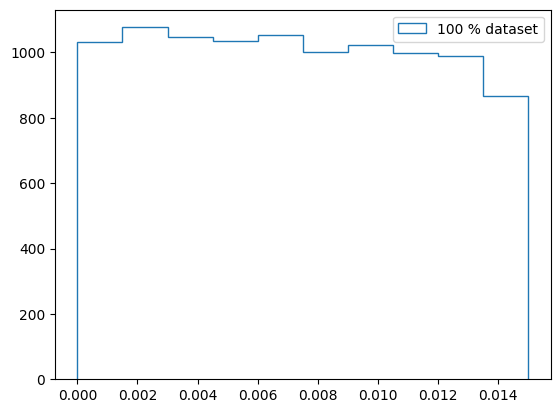

In [49]:
Nzbins, zbins, _ = plt.hist(zz, histtype='step', label = '100 % dataset')
plt.legend()

In [50]:
rng = numpy.random.default_rng( seed=123 )

In [51]:
rind = rng.integers(1, endpoint=True, size=zz.size, dtype=bool)

In [52]:
rind = rng.uniform(size=zz.size)

#rind>0.5

Ok, it is quite uniform but these are a lot of objects (or they might be).

#### EXERCISE: SUB-SAMPLE A DATASET

Why not sub-sample it?

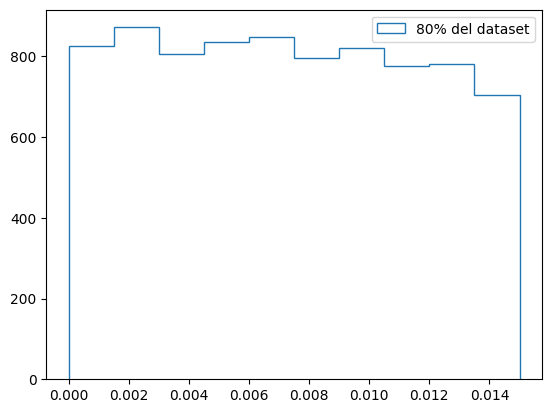

In [57]:
# insert here solution

Nzbins1, zbins1, _ = plt.hist(zz[rind > 0.2], histtype='step', label='80% del dataset') #per tenere l'80% del dataset
plt.legend()

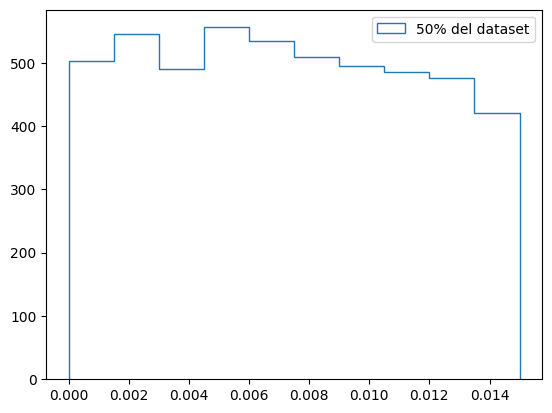

In [59]:
Nzbins2, zbins2, _ = plt.hist(zz[rind > 0.5], histtype='step', label='50% del dataset') #per tenere il 50% del dataset
plt.legend()

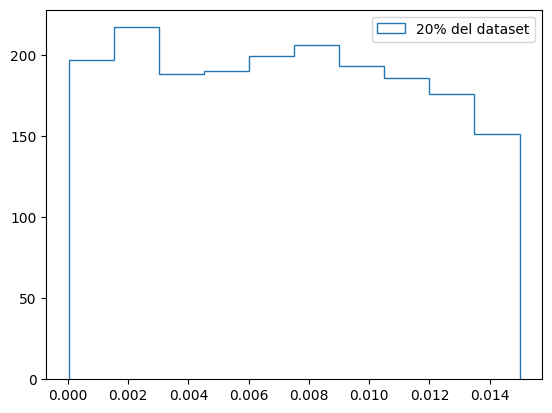

In [60]:
Nzbins3, zbins3, _ = plt.hist(zz[rind > 0.8], histtype='step', label='20% del dataset') #per tenere il 20% del dataset
plt.legend()

In [61]:
zz

array([0.00548501, 0.00201726, 0.0075549 , ..., 0.00267963, 0.01005291,
       0.00801746], shape=(10123,), dtype='>f4')

In [62]:
zz[rind > 0.2]

array([0.00548501, 0.0075549 , 0.00328725, ..., 0.00879598, 0.00267963,
       0.01005291], shape=(8064,), dtype='>f4')

In [63]:
zz[rind > 0.5]

array([0.00548501, 0.0075549 , 0.00910523, ..., 0.00714079, 0.00267963,
       0.01005291], shape=(5017,), dtype='>f4')

In [64]:
zz[rind > 0.8]

array([0.00548501, 0.0075549 , 0.01080793, ..., 0.00736137, 0.00821531,
       0.00164958], shape=(1903,), dtype='>f4')

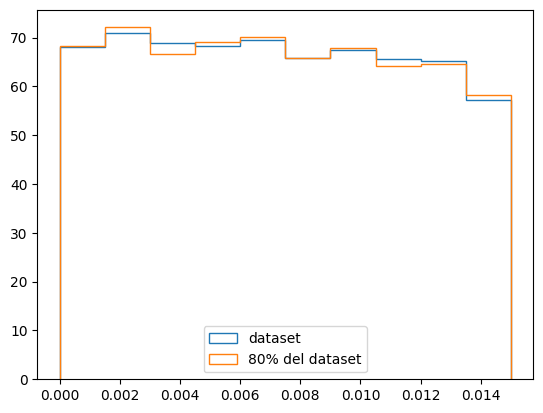

In [65]:
nz, *_ = plt.hist(zz, histtype='step', density=True, label='dataset')
nz_ss1, *_ = plt.hist(zz[rind > 0.2], histtype='step', density=True, label='80% del dataset')
plt.legend()

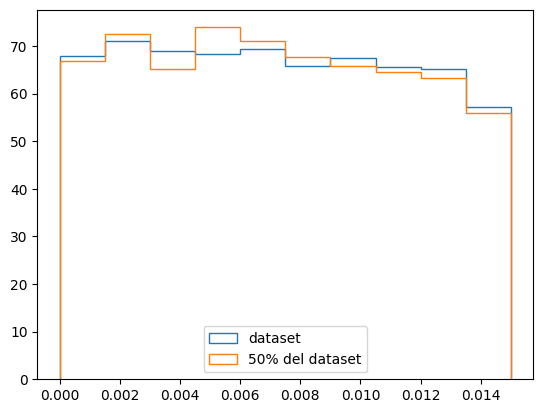

In [68]:
nz, *_ = plt.hist(zz, histtype='step', density=True, label='dataset')
nz_ss2, *_ = plt.hist(zz[rind > 0.5], histtype='step', density=True, label='50% del dataset')
plt.legend()

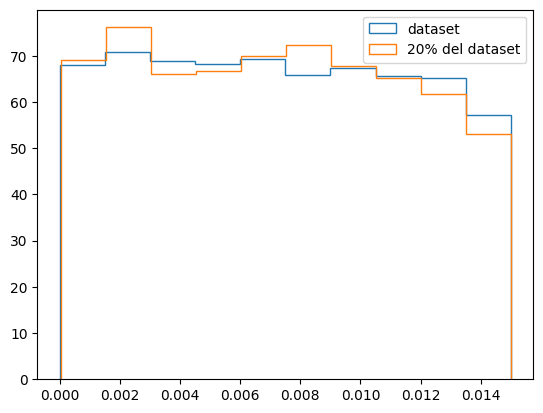

In [69]:
nz, *_ = plt.hist(zz, histtype='step', density=True, label='dataset')
nz_ss3, *_ = plt.hist(zz[rind > 0.8], histtype='step', density=True, label='20% del dataset')
plt.legend()

In [70]:
zcen = 0.5*(zbins[1:]+zbins[:-1])

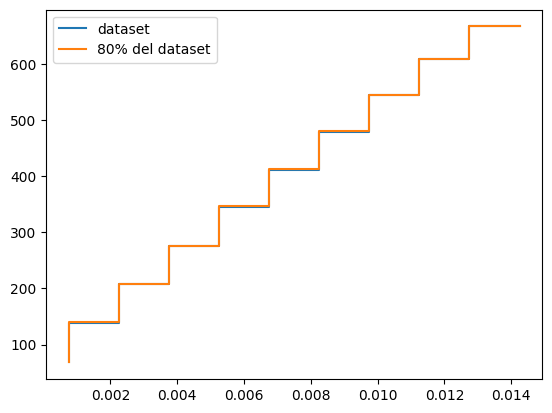

In [71]:
plt.step(zcen, nz.cumsum(), label='dataset')
plt.step(zcen, nz_ss1.cumsum(), label='80% del dataset')
plt.legend()

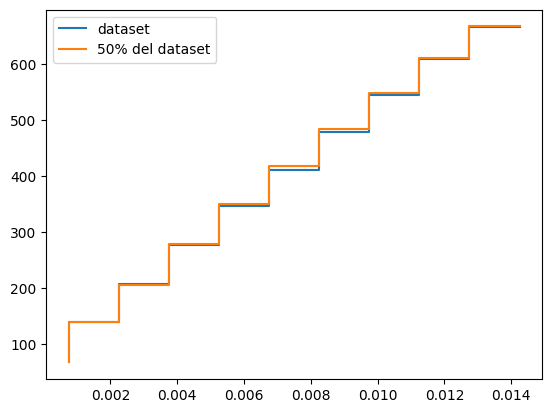

In [72]:
plt.step(zcen, nz.cumsum(), label='dataset')
plt.step(zcen, nz_ss2.cumsum(), label='50% del dataset')
plt.legend()

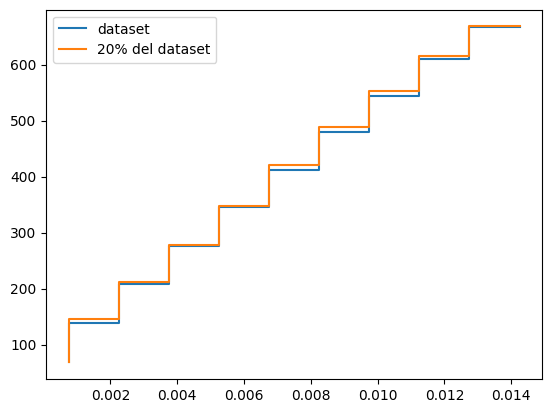

In [73]:
plt.step(zcen, nz.cumsum(), label='dataset')
plt.step(zcen, nz_ss3.cumsum(), label='20% del dataset')
plt.legend()

In [74]:
from scipy.stats import kstest

In [76]:
kstest(nz.cumsum(), nz_ss2.cumsum()).pvalue > 0.05

np.True_

### Stellar-to-halo mass relation (SHMR)

A.K.A. what stellar mass corresponds to heach DM halo mass?

In [77]:
Mh = hdul[1].data['Mh']
Ms = hdul[1].data['Mstar']

In [78]:
Ms.size

10123

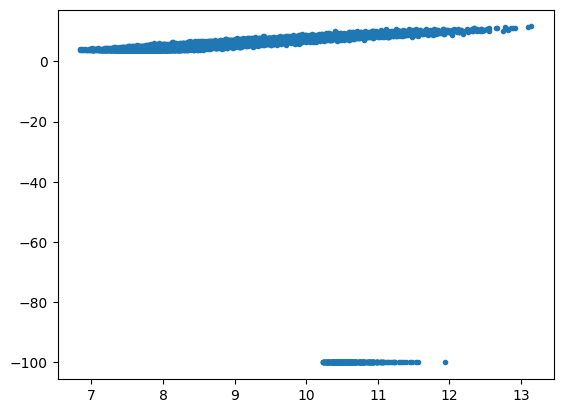

In [79]:
plt.scatter(Mh, Ms, marker='.')

In [80]:
wMs = Ms > 0.0

In [81]:
wMs.dtype, wMs.size, wMs.sum()

(dtype('bool'), 10123, np.int64(9818))

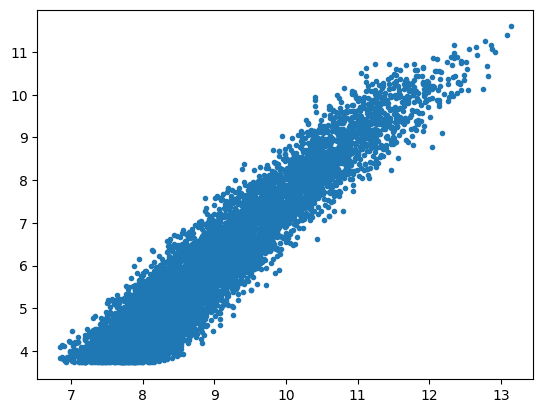

In [82]:
plt.scatter(Mh[wMs], Ms[wMs], marker='.')

Is this plot helpful? Not very much.. you just see a cloud of points, but you can understand some stuff from it, like what?

### EXERCISE: ANSWER THE QUESTIONS ABOVE AND DESIGN A BETTER PLOT

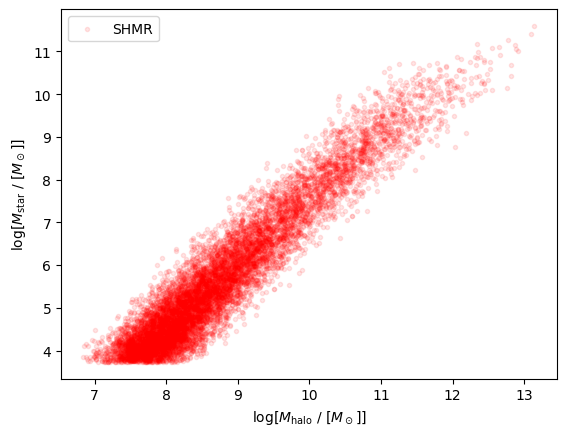

In [83]:
# insert here solution

plt.scatter(Mh[wMs], Ms[wMs], marker='.', alpha = 0.1, color = 'red', label = 'SHMR')
plt.xlabel('$\\log [M_\\mathrm{halo} \\ / \\ [M_\\odot] ]$')
plt.ylabel('$\\log [M_\\mathrm{star} \\ / \\ [M_\\odot] ]$')
plt.legend()

Dal grafico è possibile vedere la presenza di una correlazione positiva (approssimativamente lineare) tra le due grandezze in scala logaritmica, portando quindi a presupporre una relazione di legge di potenza tra le due quantità $M_{star}$ e $M_{halo}$, che però potrebbe differire in base all'intervallo di valori delle masse considerate.

## To conclude, we will use this notebook also to extract some data and use them in a second moment:

I want to see how the SFR is distributed across my catalogue. i.e. I want to compute the
**SFR density function**

I am extracting here the value array

In [61]:
lSFR = hdul[1].data['logSFR']

And once again I can see how this dataset is distributed

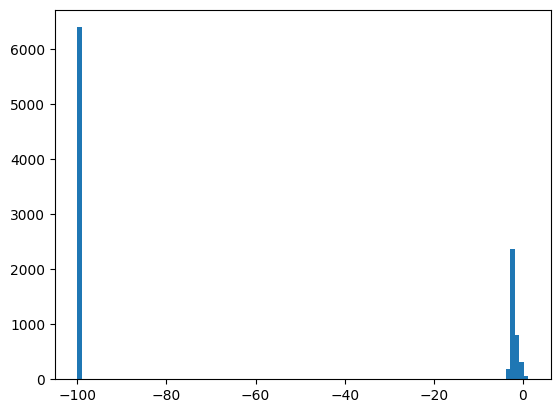

In [62]:
_ = plt.hist(lSFR, bins=100)

Since I notice there is an excess of objects with the same SFR value (i.e. $\log\text{SFR} = -100$) I can conclude those are *flagged values* (i.e. no measurement is provided)

In [63]:
wSFR = lSFR>-100.0

To get the density I need the volume, what is the volume of a lightcone?

$$V_\text{FoV} = \dfrac{\Omega}{3}d_C^3(z)$$

with $\Omega$ solid angle and $d_C(z)$ the comoving distance.

Some information I am giving you here "for free"

In [64]:
FoV = 5 # deg
degrees_to_radians = numpy.pi / 180
SolidAngle = (FoV*degrees_to_radians)**2
Volume = 0.333333 * SolidAngle * (Planck18.comoving_distance(zz.max()))**3

In [65]:
Volume

<Quantity 737.41420668 Mpc3>

I can check once again the limits of my sample to get some indication of the bin limits. 

In [66]:
lSFR[wSFR].min(), lSFR[wSFR].max()

(np.float64(-2.8748536109924316), np.float64(1.2258739471435547))

Compute the histogram

In [67]:
NlSFR, lSFR_bins = numpy.histogram( lSFR[wSFR], bins=numpy.linspace(-3, 1.5, 30) )
lSFR_cens = 0.5*(lSFR_bins[1:]+lSFR_bins[:-1])

and get my **SUMMARY STATISTICS**

In [68]:
nlSFR = NlSFR / Volume.value
nlSFR_err = numpy.sqrt( NlSFR ) / Volume.value

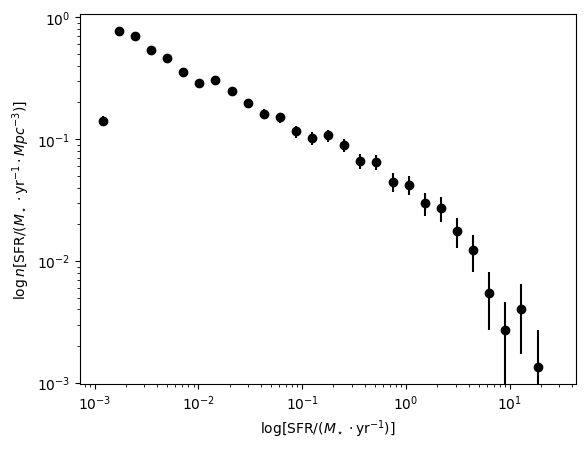

In [69]:
fig, ax = plt.subplots(1,1)
_ = ax.set(
    xscale='log', yscale='log',
    xlabel='$\\log [\\mathrm{SFR}/(M_\\star\\cdot\\mathrm{yr}^{-1})]$',
    ylabel='$\\log n[\\mathrm{SFR}/(M_\\star\\cdot\\mathrm{yr}^{-1}\\cdot Mpc^{-3})]$'
)
_ = ax.errorbar(10**lSFR_cens, nlSFR, yerr=nlSFR_err, 
                marker='o', linestyle='none', color='k', label='data')

In [70]:
lSFR[wSFR].min(), lSFR[wSFR].max()

(np.float64(-2.8748536109924316), np.float64(1.2258739471435547))

In [71]:
lSFR_cens

array([-2.92241379, -2.76724138, -2.61206897, -2.45689655, -2.30172414,
       -2.14655172, -1.99137931, -1.8362069 , -1.68103448, -1.52586207,
       -1.37068966, -1.21551724, -1.06034483, -0.90517241, -0.75      ,
       -0.59482759, -0.43965517, -0.28448276, -0.12931034,  0.02586207,
        0.18103448,  0.3362069 ,  0.49137931,  0.64655172,  0.80172414,
        0.95689655,  1.11206897,  1.26724138,  1.42241379])

In [72]:
nlSFR

array([0.14103336, 0.77297128, 0.7024546 , 0.53701162, 0.46513886,
       0.35665166, 0.28613498, 0.30376415, 0.24545228, 0.19663304,
       0.16001861, 0.15052599, 0.11526765, 0.10170675, 0.10713111,
       0.08950194, 0.06644841, 0.06509232, 0.04475097, 0.04203879,
       0.02983398, 0.0271218 , 0.01762917, 0.01220481, 0.00542436,
       0.00271218, 0.00406827, 0.00135609, 0.        ])

In [73]:
outfile = os.path.join(basedir, 'SFR_density_function')
outfile

'/home/carlabertacche/myproject/PracticalProgrammingToolkit/hands_on/H03/datasets/SFR_density_function'

> Let's save the data (notice that I am ignoring the first and two-before-last data-points, why did I do that?) 

In [74]:
numpy.savez(outfile, lsfr = lSFR_cens[1:-2], nsfr = nlSFR[1:-2], nsfr_e = nlSFR_err[1:-2])